In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('converted_spreadsheet.csv')
# df= df.drop(columns=['exp no','Source Report', 'Force', 'Area'], axis=1)

In [3]:
df.columns

Index(['Run', 'Infill Density (%)', 'Nozzle Temperature (C)', 'Infill Pattern',
       'Mean Tensile Stress', 'Standard Deviation'],
      dtype='object')

In [4]:
df

,Run,Infill Density (%),Nozzle Temperature (C),Infill Pattern,Mean Tensile Stress,Standard Deviation
0,1,60.0000,260.000,Triangle-Hexa,14.435306,0.198376
1,2,45.8579,254.142,Grid,12.458722,0.320792
2,3,60.0000,240.000,Triangle,12.676306,0.224385
3,4,74.1421,225.858,Grid,13.669444,0.288289
4,5,45.8579,222.858,Triangle-Hexa,11.082694,0.281359
5,6,60.0000,240.000,Grid,13.943194,0.231905
6,7,45.8579,225.858,Triangle,9.696944,0.285871
7,8,40.0000,240.000,Triangle-Hexa,10.700583,0.231713
8,9,74.1421,254.142,Triangle,17.711028,0.219842
9,10,60.0000,240.000,Triangle-Hexa,12.640278,0.443573


In [5]:
# import pandas as pd
# from pandasql import sqldf

# # Let's assume 'df' is the name of your original dataframe
# df = pd.read_csv('99 dataset finally - Sheet1.csv')

# # 1. Define a lambda function for easier querying
# pysqldf = lambda q: sqldf(q, globals())

# query = """

# SELECT DISTINCT('Run'), 'Infill Density (%)', 'Nozzle Temperature (C)','Infill Pattern', AVG('Tensile Stress') AS Mean_Tensile_Stress
# from df
# GROUP BY 'Infill Density (%)', 'Nozzle Temperature (C)', 'Infill Pattern'


# """

# sql_results = pysqldf(query)

# print(sql_results)

In [6]:
df.describe()

,Run,Infill Density (%),Nozzle Temperature (C),Mean Tensile Stress,Standard Deviation
count,33.00000,33.000000,33.000000,33.000000,33.000000
mean,17.00000,60.000000,239.909091,13.370323,0.254157
std,9.66954,12.247433,12.366200,2.631140,0.099746
min,1.00000,40.000000,220.000000,8.416611,0.113063
25%,9.00000,45.857900,225.858000,11.082694,0.176465
50%,17.00000,60.000000,240.000000,13.669444,0.231713
75%,25.00000,74.142100,254.142000,14.512472,0.315083
max,33.00000,80.000000,260.000000,18.474722,0.596045


In [7]:
# one-hot encode the 'Infill Pattern' column
df_encoded = pd.get_dummies(df, columns=['Infill Pattern'])
df_encoded['Infill Pattern_Grid'] = df_encoded['Infill Pattern_Grid'].astype(int)
df_encoded['Infill Pattern_Triangle'] = df_encoded['Infill Pattern_Triangle'].astype(int)
df_encoded['Infill Pattern_Triangle-Hexa'] = df_encoded['Infill Pattern_Triangle-Hexa'].astype(int)



In [8]:
df_encoded[['Infill Pattern_Grid', 'Infill Pattern_Triangle', 'Infill Pattern_Triangle-Hexa']].head(10)

,Infill Pattern_Grid,Infill Pattern_Triangle,Infill Pattern_Triangle-Hexa
0,0,0,1
1,1,0,0
2,0,1,0
3,1,0,0
4,0,0,1
5,1,0,0
6,0,1,0
7,0,0,1
8,0,1,0
9,0,0,1


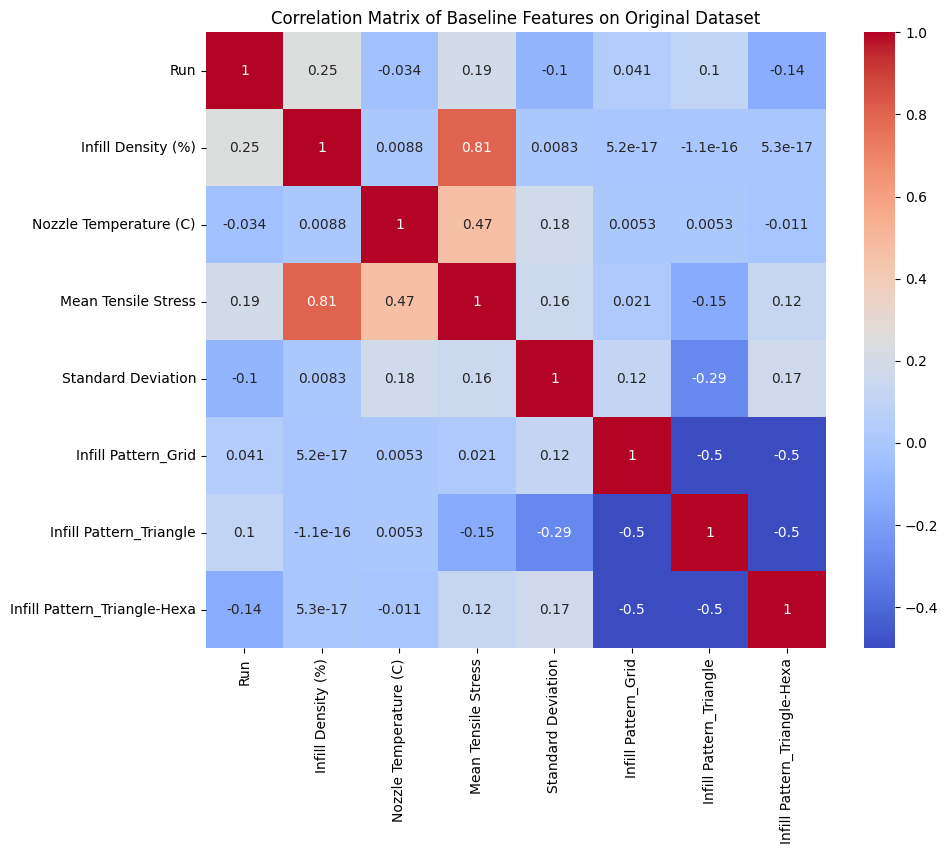

In [9]:
from matplotlib import pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8))
correlation_matrix = df_encoded.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Baseline Features on Original Dataset')
plt.show()

## Effective Area ($A_{eff}$)

In [10]:
# Create a mapping for the Geometry Factor
# Note: Since your data is one-hot encoded, we multiply by the column indicator
df_encoded['Effective Load-Bearing Area (Aeff)'] = df_encoded['Infill Density (%)'] * (
    (df_encoded['Infill Pattern_Triangle-Hexa'] * 1.0) +
    (df_encoded['Infill Pattern_Triangle'] * 0.85) +
    (df_encoded['Infill Pattern_Grid'] * 0.70)
)

## polymer difusin rate

In [11]:
import numpy as np

# 1. Define Constants
Ea = 68000  # Activation Energy for PA6 (J/mol)
R = 8.314    # Gas Constant
T_kelvin = df_encoded['Nozzle Temperature (C)'] + 273.15

# 2. Calculate Polymer Diffusion Rate
# We can set D0 = 1 for relative comparison
df_encoded['Diffusion Rate'] = np.exp(-Ea / (R * T_kelvin))

# 3. Normalize it so it stays on a 0-1 scale like your other features
df_encoded['Diffusion_Rate_Normalized'] = (df_encoded['Diffusion Rate'] - df_encoded['Diffusion Rate'].min()) / \
                                          (df_encoded['Diffusion Rate'].max() - df_encoded['Diffusion Rate'].min())

In [12]:
df_encoded

,Run,Infill Density (%),Nozzle Temperature (C),Mean Tensile Stress,Standard Deviation,Infill Pattern_Grid,Infill Pattern_Triangle,Infill Pattern_Triangle-Hexa,Effective Load-Bearing Area (Aeff),Diffusion Rate,Diffusion_Rate_Normalized
0,1,60.0000,260.000,14.435306,0.198376,0,0,1,60.000000,2.175468e-07,1.000000
1,2,45.8579,254.142,12.458722,0.320792,1,0,0,32.100530,1.834575e-07,0.779875
2,3,60.0000,240.000,12.676306,0.224385,0,1,0,51.000000,1.196421e-07,0.367799
3,4,74.1421,225.858,13.669444,0.288289,1,0,0,51.899470,7.615698e-08,0.087002
4,5,45.8579,222.858,11.082694,0.281359,0,0,1,45.857900,6.896936e-08,0.040590
5,6,60.0000,240.000,13.943194,0.231905,1,0,0,42.000000,1.196421e-07,0.367799
6,7,45.8579,225.858,9.696944,0.285871,0,1,0,38.979215,7.615698e-08,0.087002
7,8,40.0000,240.000,10.700583,0.231713,0,0,1,40.000000,1.196421e-07,0.367799
8,9,74.1421,254.142,17.711028,0.219842,0,1,0,63.020785,1.834575e-07,0.779875
9,10,60.0000,240.000,12.640278,0.443573,0,0,1,60.000000,1.196421e-07,0.367799


# physics augmented corrilation

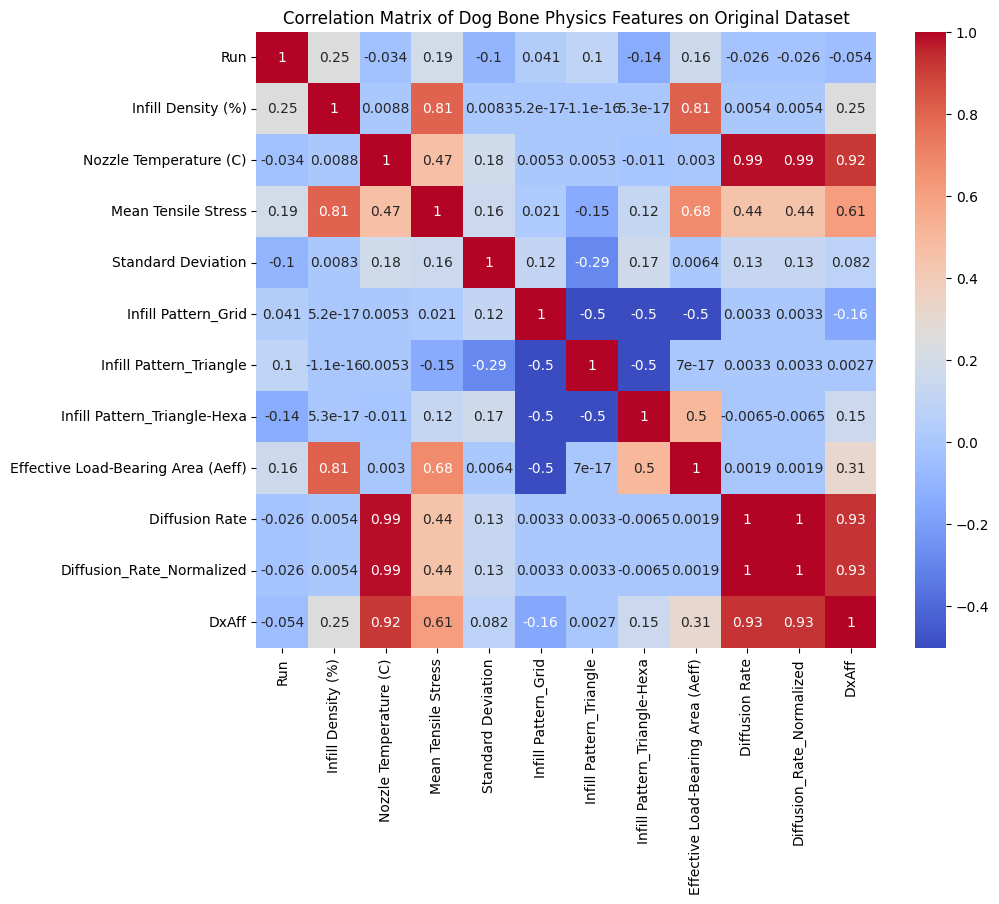

In [13]:
df_encoded['DxAff'] = df_encoded['Effective Load-Bearing Area (Aeff)'] * df_encoded['Diffusion_Rate_Normalized']

from matplotlib import pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8))
correlation_matrix = df_encoded.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Dog Bone Physics Features on Original Dataset')
plt.show()

# Features defination

In [14]:
# Physics-Augmented Features

FEATURES_PHYSICS = [
    # 'Infill Density (%)', ## comment this has been droped for using IVF in augmneted results
    'Infill Pattern_Grid', 
    'Infill Pattern_Triangle', 
    'Infill Pattern_Triangle-Hexa', 
    'Effective Load-Bearing Area (Aeff)',
    # 'Diffusion_Rate_Normalized',
    'DxAff'
]


# Baseline Features (Standard Engineering)
FEATURES_BASE = [
    'Infill Density (%)', 
    'Nozzle Temperature (C)', 
    'Infill Pattern_Grid', 
    'Infill Pattern_Triangle', 
    'Infill Pattern_Triangle-Hexa'
]

# Defining the target
target = 'Mean Tensile Stress'


# RF Baseline

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split

X_base = df_encoded[FEATURES_BASE]
y = df_encoded[target]

# base features
X_train_base, X_test, y_train, y_test = train_test_split(X_base, y, test_size=0.2, random_state=42)


# Print the shapes of the new datasets to verify the split
print(f'Shape of X_train: {X_train_base.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (26, 5)
Shape of X_test: (7, 5)
Shape of y_train: (26,)
Shape of y_test: (7,)


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

rf_base = RandomForestRegressor(
    n_estimators=500,       # More trees for better variance reduction
    max_depth=None,         # Let trees grow, but control them with samples_leaf
    min_samples_split=5,    # Requires more data to create a branch
    min_samples_leaf=2,     # Lower this (from 7) to capture more detail
    max_features='sqrt',    # CRITICAL: Forces trees to be different; helps generalization
    bootstrap=True,
    oob_score=True,         # Use Out-Of-Bag score as an extra validation metric
    random_state=42,
    n_jobs=-1
)
rf_base.fit(X_train_base, y_train)

y_pred = rf_base.predict(X_test)

rf_r2_base  = r2_score(y_test, y_pred)
rf_mse_base = mean_squared_error(y_test, y_pred)
rf_rmse_base = np.sqrt(rf_mse_base)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()
rf_acc_2_5_base = tolerance_accuracy(y_test.values, y_pred, 0.25)
rf_acc_05_base = tolerance_accuracy(y_test.values, y_pred, 0.5)
rf_acc_10_base = tolerance_accuracy(y_test.values, y_pred, 1.0)
rf_acc_20_base = tolerance_accuracy(y_test.values, y_pred, 2.0)
rf_acc_30_base = tolerance_accuracy(y_test.values, y_pred, 3.0)
print(f"=== Random Forest Prediction (Test) for BaseLine Features ===")
print(f"R²          : {rf_r2_base:.4f}")
print(f"RMSE        : {rf_rmse_base:.3f} MPa")
print(f"MSE         : {rf_mse_base:.4f} MPa")
print("Accuracy (Relative to Target Range 8.0-19.0 MPa):")
print(f"  High Precision (±0.25 MPa): {rf_acc_2_5_base* 100:5.2f}%")
print(f"  Engineering    (±0.50 MPa): {rf_acc_05_base * 100:5.2f}%")
print(f"  Acceptable     (±1.00 MPa): {rf_acc_10_base * 100:5.2f}%")
print(f"  Upper Bound    (±2.00 MPa): {rf_acc_20_base * 100:5.2f}%")

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# 2. Run cross-validation using the_BASE tscv object
rf_cv_r2_base = cross_val_score(rf_base, X_base, y, cv=kf, scoring='r2', n_jobs=-1)

print("\n=== KFolf CV Evaluation Marix for BaseLine Features ===")
print(f"Mean R² : {rf_cv_r2_base.mean():.4f}  (±{rf_cv_r2_base.std():.4f})")
print(f"Scores  : {np.round(rf_cv_r2_base, 4)}")

rf_cv_r2_base = rf_cv_r2_base.mean()

fi = pd.DataFrame({
    'feature'   : FEATURES_BASE,
    'importance': rf_base.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))


=== Random Forest Prediction (Test) for BaseLine Features ===
R²          : 0.2564
RMSE        : 2.073 MPa
MSE         : 4.2973 MPa
Accuracy (Relative to Target Range 8.0-19.0 MPa):
  High Precision (±0.25 MPa):  0.00%
  Engineering    (±0.50 MPa): 14.29%
  Acceptable     (±1.00 MPa): 14.29%
  Upper Bound    (±2.00 MPa): 71.43%

=== KFolf CV Evaluation Marix for BaseLine Features ===
Mean R² : 0.4625  (±0.1325)
Scores  : [0.3303 0.4167 0.3333 0.6627 0.5693]

=== Feature Importances (Top 10) ===
                     feature  importance
          Infill Density (%)    0.629630
      Nozzle Temperature (C)    0.181207
     Infill Pattern_Triangle    0.089248
Infill Pattern_Triangle-Hexa    0.066241
         Infill Pattern_Grid    0.033673


# rf physics

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split

X_physics = df_encoded[FEATURES_PHYSICS]
y = df_encoded[target]

# physics features
X_train_physics, X_test, y_train, y_test = train_test_split(X_physics, y, test_size=0.2, random_state=42)


# Print the shapes of the new datasets to verify the split
print(f'Shape of X_train: {X_train_physics.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (26, 5)
Shape of X_test: (7, 5)
Shape of y_train: (26,)
Shape of y_test: (7,)


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

rf_physics = RandomForestRegressor(
    n_estimators=500,       # More trees for better variance reduction
    max_depth=None,         # Let trees grow, but control them with samples_leaf
    min_samples_split=5,    # Requires more data to create a branch
    min_samples_leaf=2,     # Lower this (from 7) to capture more detail
    max_features='sqrt',    # CRITICAL: Forces trees to be different; helps generalization
    bootstrap=True,
    oob_score=True,         # Use Out-Of-Bag score as an extra validation metric
    random_state=42,
    n_jobs=-1
)
rf_physics.fit(X_train_physics, y_train)

y_pred = rf_physics.predict(X_test)

rf_r2_physics  = r2_score(y_test, y_pred)
rf_mse_physics = mean_squared_error(y_test, y_pred)
rf_rmse_physics = np.sqrt(rf_mse_physics)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()
rf_acc_2_5_physics = tolerance_accuracy(y_test.values, y_pred, 0.25)
rf_acc_05_physics = tolerance_accuracy(y_test.values, y_pred, 0.5)
rf_acc_10_physics = tolerance_accuracy(y_test.values, y_pred, 1.0)
rf_acc_20_physics = tolerance_accuracy(y_test.values, y_pred, 2.0)
rf_acc_30_physics = tolerance_accuracy(y_test.values, y_pred, 3.0)

print(f"=== Random Forest Prediction (Test) for Physics Augmented Features ===")
print(f"R²          : {rf_r2_physics:.4f}")
print(f"RMSE        : {rf_rmse_physics:.3f} MPa")
print(f"MSE         : {rf_mse_physics:.4f} MPa")
print("Accuracy (Relative to Target Range 8.0-19.0 MPa):")
print(f"  High Precision (±0.25 MPa): { rf_acc_2_5_physics* 100:5.2f}%")
print(f"  Engineering    (±0.50 MPa): {rf_acc_05_physics * 100:5.2f}%")
print(f"  Acceptable     (±1.00 MPa): {rf_acc_10_physics * 100:5.2f}%")
print(f"  Upper Bound    (±2.00 MPa): {rf_acc_20_physics * 100:5.2f}%")

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# 2. Run cross-validation using the_BASE tscv object
rf_cv_r2_physics = cross_val_score(rf_physics, X_physics, y, cv=kf, scoring='r2', n_jobs=-1)

print("\n=== KFolf CV Evaluation Marix for Physics Augmented Features ===")
print(f"Mean R² : {rf_cv_r2_physics.mean():.4f}  (±{rf_cv_r2_physics.std():.4f})")
print(f"Scores  : {np.round(rf_cv_r2_physics, 4)}")

rf_cv_r2_physics = rf_cv_r2_physics.mean()

fi = pd.DataFrame({
    'feature'   : FEATURES_PHYSICS,
    'importance': rf_physics.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))

=== Random Forest Prediction (Test) for Physics Augmented Features ===
R²          : 0.2697
RMSE        : 2.054 MPa
MSE         : 4.2203 MPa
Accuracy (Relative to Target Range 8.0-19.0 MPa):
  High Precision (±0.25 MPa):  0.00%
  Engineering    (±0.50 MPa):  0.00%
  Acceptable     (±1.00 MPa): 42.86%
  Upper Bound    (±2.00 MPa): 57.14%

=== KFolf CV Evaluation Marix for Physics Augmented Features ===
Mean R² : 0.4555  (±0.1272)
Scores  : [0.2509 0.5325 0.3635 0.5511 0.5798]

=== Feature Importances (Top 10) ===
                           feature  importance
Effective Load-Bearing Area (Aeff)    0.480827
                             DxAff    0.401802
           Infill Pattern_Triangle    0.053655
      Infill Pattern_Triangle-Hexa    0.036449
               Infill Pattern_Grid    0.027266


# XGBoost baseline


In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split

X_base = df_encoded[FEATURES_BASE]
y = df_encoded[target]

# base features
X_train_base, X_test, y_train, y_test = train_test_split(X_base, y, test_size=0.2, random_state=42)


# Print the shapes of the new datasets to verify the split
print(f'Shape of X_train: {X_train_base.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (26, 5)
Shape of X_test: (7, 5)
Shape of y_train: (26,)
Shape of y_test: (7,)


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

xgb_base = RandomForestRegressor(
    n_estimators=500,       # More trees for better variance reduction
    max_depth=None,         # Let trees grow, but control them with samples_leaf
    min_samples_split=5,    # Requires more data to create a branch
    min_samples_leaf=2,     # Lower this (from 7) to capture more detail
    max_features='sqrt',    # CRITICAL: Forces trees to be different; helps generalization
    bootstrap=True,
    oob_score=True,         # Use Out-Of-Bag score as an extra validation metric
    random_state=42,
    n_jobs=-1
)
xgb_base.fit(X_train_base, y_train)

y_pred = xgb_base.predict(X_test)

xgb_r2_base  = r2_score(y_test, y_pred)
xgb_mse_base = mean_squared_error(y_test, y_pred)
xgb_rmse_base = np.sqrt(xgb_mse_base)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()
xgb_acc_2_5_base= tolerance_accuracy(y_test.values, y_pred, 0.25)
xgb_acc_05_base = tolerance_accuracy(y_test.values, y_pred, 0.5)
xgb_acc_10_base = tolerance_accuracy(y_test.values, y_pred, 1.0)
xgb_acc_20_base = tolerance_accuracy(y_test.values, y_pred, 2.0)
xgb_acc_30_base = tolerance_accuracy(y_test.values, y_pred, 3.0)

print(f"=== XGBoost Prediction (Test) for BaseLine Features ===")
print(f"R²          : {xgb_r2_base:.4f}")
print(f"RMSE        : {xgb_rmse_base:.3f} MPa")
print(f"MSE         : {xgb_mse_base:.4f} MPa")
print("Accuracy (Relative to Target Range 8.0-19.0 MPa):")
print(f"  High Precision (±0.25 MPa): {xgb_acc_2_5_base * 100:5.2f}%")
print(f"  Engineering    (±0.50 MPa): {xgb_acc_05_base * 100:5.2f}%")
print(f"  Acceptable     (±1.00 MPa): {xgb_acc_10_base * 100:5.2f}%")
print(f"  Upper Bound    (±2.00 MPa): {xgb_acc_20_base * 100:5.2f}%")

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# 2. Run cross-validation using the_BASE tscv object
xgb_cv_r2_base = cross_val_score(xgb_base, X_base, y, cv=kf, scoring='r2', n_jobs=-1)

print("\n=== KFolf CV Evaluation Marix for Baseline Features ===")
print(f"Mean R² : {xgb_cv_r2_base.mean():.4f}  (±{xgb_cv_r2_base.std():.4f})")
print(f"Scores  : {np.round(xgb_cv_r2_base, 4)}")

xgb_cv_r2_base = xgb_cv_r2_base.mean()

fi = pd.DataFrame({
    'feature'   : FEATURES_BASE,
    'importance': xgb_base.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))

=== XGBoost Prediction (Test) for BaseLine Features ===
R²          : 0.2564
RMSE        : 2.073 MPa
MSE         : 4.2973 MPa
Accuracy (Relative to Target Range 8.0-19.0 MPa):
  High Precision (±0.25 MPa):  0.00%
  Engineering    (±0.50 MPa): 14.29%
  Acceptable     (±1.00 MPa): 14.29%
  Upper Bound    (±2.00 MPa): 71.43%

=== KFolf CV Evaluation Marix for Baseline Features ===
Mean R² : 0.4625  (±0.1325)
Scores  : [0.3303 0.4167 0.3333 0.6627 0.5693]

=== Feature Importances (Top 10) ===
                     feature  importance
          Infill Density (%)    0.629630
      Nozzle Temperature (C)    0.181207
     Infill Pattern_Triangle    0.089248
Infill Pattern_Triangle-Hexa    0.066241
         Infill Pattern_Grid    0.033673


# XGBoost Physics

In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split

X_physics = df_encoded[FEATURES_PHYSICS]
y = df_encoded[target]

# physics features
X_train_physics, X_test, y_train, y_test = train_test_split(X_physics, y, test_size=0.2, random_state=42)


# Print the shapes of the new datasets to verify the split
print(f'Shape of X_train: {X_train_physics.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (26, 5)
Shape of X_test: (7, 5)
Shape of y_train: (26,)
Shape of y_test: (7,)


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

xgb_physics = RandomForestRegressor(
    n_estimators=500,       # More trees for better variance reduction
    max_depth=None,         # Let trees grow, but control them with samples_leaf
    min_samples_split=5,    # Requires more data to create a branch
    min_samples_leaf=2,     # Lower this (from 7) to capture more detail
    max_features='sqrt',    # CRITICAL: Forces trees to be different; helps generalization
    bootstrap=True,
    oob_score=True,         # Use Out-Of-Bag score as an extra validation metric
    random_state=42,
    n_jobs=-1
)
xgb_physics.fit(X_train_physics, y_train)

y_pred = xgb_physics.predict(X_test)

xgb_r2_physics  = r2_score(y_test, y_pred)
xgb_mse_physics = mean_squared_error(y_test, y_pred)
xgb_rmse_physics = np.sqrt(xgb_mse_physics)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()

xgb_acc_2_5_physics = tolerance_accuracy(y_test.values, y_pred, 0.25)
xgb_acc_05_physics = tolerance_accuracy(y_test.values, y_pred, 0.5)
xgb_acc_10_physics = tolerance_accuracy(y_test.values, y_pred, 1.0)
xgb_acc_20_physics = tolerance_accuracy(y_test.values, y_pred, 2.0)
xgb_acc_30_physics = tolerance_accuracy(y_test.values, y_pred, 3.0)

print(f"=== XGBoost Prediction (Test) for Physics Augmented Features ===")
print(f"R²          : {xgb_r2_physics:.4f}")
print(f"RMSE        : {xgb_rmse_physics:.3f} MPa")
print(f"MSE         : {xgb_mse_physics:.4f} MPa")
print("Accuracy (Relative to Target Range 8.0-19.0 MPa):")
print(f"  High Precision (±0.25 MPa): {xgb_acc_2_5_physics* 100:5.2f}%")
print(f"  Engineering    (±0.50 MPa): {xgb_acc_05_physics * 100:5.2f}%")
print(f"  Acceptable     (±1.00 MPa): {xgb_acc_10_physics * 100:5.2f}%")
print(f"  Upper Bound    (±2.00 MPa): {xgb_acc_20_physics * 100:5.2f}%")

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# 2. Run cross-validation using the_BASE tscv object
xgb_cv_r2_physics = cross_val_score(xgb_physics, X_physics, y, cv=kf, scoring='r2', n_jobs=-1)

print("\n=== KFolf CV Evaluation Marix for Physics Augmented Features ===")
print(f"Mean R² : {xgb_cv_r2_physics.mean():.4f}  (±{xgb_cv_r2_physics.std():.4f})")
print(f"Scores  : {np.round(xgb_cv_r2_physics, 4)}")

xgb_cv_r2_physics = xgb_cv_r2_physics.mean()

fi = pd.DataFrame({
    'feature'   : FEATURES_PHYSICS,
    'importance': xgb_physics.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))

=== XGBoost Prediction (Test) for Physics Augmented Features ===
R²          : 0.2697
RMSE        : 2.054 MPa
MSE         : 4.2203 MPa
Accuracy (Relative to Target Range 8.0-19.0 MPa):
  High Precision (±0.25 MPa):  0.00%
  Engineering    (±0.50 MPa):  0.00%
  Acceptable     (±1.00 MPa): 42.86%
  Upper Bound    (±2.00 MPa): 57.14%

=== KFolf CV Evaluation Marix for Physics Augmented Features ===
Mean R² : 0.4555  (±0.1272)
Scores  : [0.2509 0.5325 0.3635 0.5511 0.5798]

=== Feature Importances (Top 10) ===
                           feature  importance
Effective Load-Bearing Area (Aeff)    0.480827
                             DxAff    0.401802
           Infill Pattern_Triangle    0.053655
      Infill Pattern_Triangle-Hexa    0.036449
               Infill Pattern_Grid    0.027266


# LightGBM base

In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split

X_base = df_encoded[FEATURES_BASE]
y = df_encoded[target]

# base features
X_train_base, X_test, y_train, y_test = train_test_split(X_base, y, test_size=0.2, random_state=42)


# Print the shapes of the new datasets to verify the split
print(f'Shape of X_train: {X_train_base.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (26, 5)
Shape of X_test: (7, 5)
Shape of y_train: (26,)
Shape of y_test: (7,)


In [25]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score,TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor
import lightgbm as lgb

lgb_base = lgb.LGBMRegressor(
    boosting_type='dart',      # Helps prevent overfitting on small datasets
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=15,             # Keep this low for small N
    max_depth=4,
    feature_fraction=0.8,
    random_state=42,
    verbosity=-1 
)

lgb_base.fit(X_train_base, y_train)

y_pred = lgb_base.predict(X_test)

lgb_r2_base  = r2_score(y_test, y_pred)
lgb_mse_base = mean_squared_error(y_test, y_pred)
lgb_rmse_base = np.sqrt(lgb_mse_base)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()

lgb_acc_2_5_base = tolerance_accuracy(y_test.values, y_pred, 0.25)
lgb_acc_05_base = tolerance_accuracy(y_test.values, y_pred, 0.5)
lgb_acc_10_base = tolerance_accuracy(y_test.values, y_pred, 1.0)
lgb_acc_20_base = tolerance_accuracy(y_test.values, y_pred, 2.0)
lgb_acc_30_base = tolerance_accuracy(y_test.values, y_pred, 3.0)

print(f"=== Light GBM Prediction (Test) for BaseLine Features ===")
print(f"R²          : {lgb_r2_base:.4f}")
print(f"RMSE        : {lgb_rmse_base:.3f} MPa")
print(f"MSE         : {lgb_mse_base:.4f} MPa")
print("Accuracy (Relative to Target Range 8.0-19.0 MPa):")
print(f"  High Precision (±0.25 MPa): {lgb_acc_2_5_base * 100:5.2f}%")
print(f"  Engineering    (±0.50 MPa): {lgb_acc_05_base * 100:5.2f}%")
print(f"  Acceptable     (±1.00 MPa): {lgb_acc_10_base * 100:5.2f}%")
print(f"  Upper Bound    (±2.00 MPa): {lgb_acc_20_base * 100:5.2f}%")

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# 2. Run cross-validation using the_BASE tscv object
lgb_cv_r2_base = cross_val_score(lgb_base, X_base, y, cv=kf, scoring='r2', n_jobs=-1)

print("\n=== KFolf CV Evaluation Marix for BaseLine Features ===")
print(f"Mean R² : {lgb_cv_r2_base.mean():.4f}  (±{lgb_cv_r2_base.std():.4f})")
print(f"Scores  : {np.round(lgb_cv_r2_base, 4)}")

lgb_cv_r2_base = lgb_cv_r2_base.mean()

fi = pd.DataFrame({
    'feature'   : FEATURES_BASE,
    'importance': lgb_base.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))

=== Light GBM Prediction (Test) for BaseLine Features ===
R²          : -0.3826
RMSE        : 2.827 MPa
MSE         : 7.9899 MPa
Accuracy (Relative to Target Range 8.0-19.0 MPa):
  High Precision (±0.25 MPa):  0.00%
  Engineering    (±0.50 MPa): 14.29%
  Acceptable     (±1.00 MPa): 28.57%
  Upper Bound    (±2.00 MPa): 57.14%

=== KFolf CV Evaluation Marix for BaseLine Features ===
Mean R² : -0.3083  (±0.2335)
Scores  : [-0.3826 -0.4485 -0.6302 -0.0378 -0.0425]

=== Feature Importances (Top 10) ===
                     feature  importance
          Infill Density (%)           0
      Nozzle Temperature (C)           0
         Infill Pattern_Grid           0
     Infill Pattern_Triangle           0
Infill Pattern_Triangle-Hexa           0


# LGB physics

In [26]:
import pandas as pd
from sklearn.model_selection import train_test_split

X_physics = df_encoded[FEATURES_PHYSICS]
y = df_encoded[target]

# physics features
X_train_physics, X_test, y_train, y_test = train_test_split(X_physics, y, test_size=0.2, random_state=42)


# Print the shapes of the new datasets to verify the split
print(f'Shape of X_train: {X_train_physics.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (26, 5)
Shape of X_test: (7, 5)
Shape of y_train: (26,)
Shape of y_test: (7,)


In [27]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score,TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor
import lightgbm as lgb

lgb_physics = lgb.LGBMRegressor(
    boosting_type='dart',      # Helps prevent overfitting on small datasets
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=15,             # Keep this low for small N
    max_depth=4,
    feature_fraction=0.8,
    random_state=42
)

lgb_physics.fit(X_train_physics, y_train)

y_pred = lgb_physics.predict(X_test)

lgb_r2_physics  = r2_score(y_test, y_pred)
lgb_mse_physics = mean_squared_error(y_test, y_pred)
lgb_rmse_physics = np.sqrt(lgb_mse_physics)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()

lgb_acc_2_5_physics = tolerance_accuracy(y_test.values, y_pred, 0.25)
lgb_acc_05_physics = tolerance_accuracy(y_test.values, y_pred, 0.5)
lgb_acc_10_physics = tolerance_accuracy(y_test.values, y_pred, 1.0)
lgb_acc_20_physics = tolerance_accuracy(y_test.values, y_pred, 2.0)
lgb_acc_30_physics = tolerance_accuracy(y_test.values, y_pred, 3.0)

print(f"=== Light GBM Prediction (Test) for Physics augmented Features ===")
print(f"R²          : {lgb_r2_physics:.4f}")
print(f"RMSE        : {lgb_rmse_physics:.3f} MPa")
print(f"MSE         : {lgb_mse_physics:.4f} MPa")
print("Accuracy (Relative to Target Range 8.0-19.0 MPa):")
print(f"  High Precision (±0.25 MPa): { lgb_acc_2_5_physics* 100:5.2f}%")
print(f"  Engineering    (±0.50 MPa): {lgb_acc_05_physics * 100:5.2f}%")
print(f"  Acceptable     (±1.00 MPa): {lgb_acc_10_physics * 100:5.2f}%")
print(f"  Upper Bound    (±2.00 MPa): {lgb_acc_20_physics * 100:5.2f}%")

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# 2. Run cross-validation using the_physics tscv object
lgb_cv_r2_physics = cross_val_score(lgb_physics, X_physics, y, cv=kf, scoring='r2', n_jobs=-1)

print("\n=== KFolf CV Evaluation Marix for Physics augmented Features ===")
print(f"Mean R² : {lgb_cv_r2_physics.mean():.4f}  (±{lgb_cv_r2_physics.std():.4f})")
print(f"Scores  : {np.round(lgb_cv_r2_physics, 4)}")

lgb_cv_r2_physics = lgb_cv_r2_physics.mean()

fi = pd.DataFrame({
    'feature'   : FEATURES_PHYSICS,
    'importance': lgb_physics.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))

=== Light GBM Prediction (Test) for Physics augmented Features ===
R²          : -0.3826
RMSE        : 2.827 MPa
MSE         : 7.9899 MPa
Accuracy (Relative to Target Range 8.0-19.0 MPa):
  High Precision (±0.25 MPa):  0.00%
  Engineering    (±0.50 MPa): 14.29%
  Acceptable     (±1.00 MPa): 28.57%
  Upper Bound    (±2.00 MPa): 57.14%

=== KFolf CV Evaluation Marix for Physics augmented Features ===
Mean R² : -0.3083  (±0.2335)
Scores  : [-0.3826 -0.4485 -0.6302 -0.0378 -0.0425]

=== Feature Importances (Top 10) ===
                           feature  importance
               Infill Pattern_Grid           0
           Infill Pattern_Triangle           0
      Infill Pattern_Triangle-Hexa           0
Effective Load-Bearing Area (Aeff)           0
                             DxAff           0


# catboost base

In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split

X_base = df_encoded[FEATURES_BASE]
y = df_encoded[target]

# base features
X_train_base, X_test, y_train, y_test = train_test_split(X_base, y, test_size=0.2, random_state=42)


# Print the shapes of the new datasets to verify the split
print(f'Shape of X_train: {X_train_base.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (26, 5)
Shape of X_test: (7, 5)
Shape of y_train: (26,)
Shape of y_test: (7,)


In [29]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score,TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor

from catboost import CatBoostRegressor

cat_base = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.03,
    depth=4,
    l2_leaf_reg=3,
    bootstrap_type='Bernoulli',
    subsample=0.8,
    verbose=0,
    random_state=42
)

cat_base.fit(X_train_base, y_train)

y_pred = cat_base.predict(X_test)

cat_r2_base  = r2_score(y_test, y_pred)
cat_mse_base = mean_squared_error(y_test, y_pred)
cat_rmse_base = np.sqrt(cat_mse_base)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()

cat_acc_2_5_base= tolerance_accuracy(y_test.values, y_pred, 0.25)
cat_acc_05_base = tolerance_accuracy(y_test.values, y_pred, 0.5)
cat_acc_10_base = tolerance_accuracy(y_test.values, y_pred, 1.0)
cat_acc_20_base = tolerance_accuracy(y_test.values, y_pred, 2.0)
cat_acc_30_base = tolerance_accuracy(y_test.values, y_pred, 3.0)

print(f"=== CAT boost Prediction (Test) for Baseline  ===")
print(f"R²          : {cat_r2_base:.4f}")
print(f"RMSE        : {cat_rmse_base:.3f} MPa")
print(f"MSE         : {cat_mse_base:.4f} MPa")
print("Accuracy (Relative to Target Range 8.0-19.0 MPa):")
print(f"  High Precision (±0.25 MPa): {cat_acc_2_5_base* 100:5.2f}%")
print(f"  Engineering    (±0.50 MPa): {cat_acc_05_base * 100:5.2f}%")
print(f"  Acceptable     (±1.00 MPa): {cat_acc_10_base * 100:5.2f}%")
print(f"  Upper Bound    (±2.00 MPa): {cat_acc_20_base * 100:5.2f}%")

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# 2. Run cross-validation using the_base tscv object
cat_cv_r2_base = cross_val_score(cat_base, X_base, y, cv=kf, scoring='r2', n_jobs=-1)

print("\n=== KFolf CV Evaluation Marix for Baseline Features ===")
print(f"Mean R² : {cat_cv_r2_base.mean():.4f}  (±{cat_cv_r2_base.std():.4f})")
print(f"Scores  : {np.round(cat_cv_r2_base, 4)}")

cat_cv_r2_base = cat_cv_r2_base.mean()

fi = pd.DataFrame({
    'feature'   : FEATURES_BASE,
    'importance': cat_base.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))

=== CAT boost Prediction (Test) for Baseline  ===
R²          : 0.6718
RMSE        : 1.377 MPa
MSE         : 1.8963 MPa
Accuracy (Relative to Target Range 8.0-19.0 MPa):
  High Precision (±0.25 MPa):  0.00%
  Engineering    (±0.50 MPa): 28.57%
  Acceptable     (±1.00 MPa): 42.86%
  Upper Bound    (±2.00 MPa): 85.71%

=== KFolf CV Evaluation Marix for Baseline Features ===
Mean R² : 0.7961  (±0.1106)
Scores  : [0.6957 0.7036 0.7394 0.9846 0.8571]

=== Feature Importances (Top 10) ===
                     feature  importance
          Infill Density (%)   63.820825
      Nozzle Temperature (C)   22.406676
     Infill Pattern_Triangle    7.257673
Infill Pattern_Triangle-Hexa    4.305369
         Infill Pattern_Grid    2.209456


# cat physics

In [30]:
import pandas as pd
from sklearn.model_selection import train_test_split

X_physics = df_encoded[FEATURES_PHYSICS]
y = df_encoded[target]

# physics features
X_train_physics, X_test, y_train, y_test = train_test_split(X_physics, y, test_size=0.2, random_state=42)


# Print the shapes of the new datasets to verify the split
print(f'Shape of X_train: {X_train_physics.shape}')
print(f'Shape of X_test: {X_test.shape}')
print(f'Shape of y_train: {y_train.shape}')
print(f'Shape of y_test: {y_test.shape}')

Shape of X_train: (26, 5)
Shape of X_test: (7, 5)
Shape of y_train: (26,)
Shape of y_test: (7,)


In [31]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score,TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor

from catboost import CatBoostRegressor

cat_physics = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.03,
    depth=4,
    l2_leaf_reg=3,
    bootstrap_type='Bernoulli',
    subsample=0.8,
    verbose=0,
    random_state=42
)

cat_physics.fit(X_train_physics, y_train)

y_pred = cat_physics.predict(X_test)

cat_r2_physics  = r2_score(y_test, y_pred)
cat_mse_physics = mean_squared_error(y_test, y_pred)
cat_rmse_physics = np.sqrt(cat_mse_physics)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()

cat_acc_2_5_physics = tolerance_accuracy(y_test.values, y_pred, 0.25) 
cat_acc_05_physics = tolerance_accuracy(y_test.values, y_pred, 0.5)
cat_acc_10_physics = tolerance_accuracy(y_test.values, y_pred, 1.0)
cat_acc_20_physics = tolerance_accuracy(y_test.values, y_pred, 2.0)
cat_acc_30_physics = tolerance_accuracy(y_test.values, y_pred, 3.0)

print(f"=== CAT boost Prediction (Test) for Physics augmented ===")
print(f"R²          : {cat_r2_physics:.4f}")
print(f"RMSE        : {cat_rmse_physics:.3f} MPa")
print(f"MSE         : {cat_mse_physics:.4f} MPa")
print("Accuracy (Relative to Target Range 8.0-19.0 MPa):")
print(f"  High Precision (±0.25 MPa): {cat_acc_2_5_physics * 100:5.2f}%")
print(f"  Engineering    (±0.50 MPa): {cat_acc_05_physics * 100:5.2f}%")
print(f"  Acceptable     (±1.00 MPa): {cat_acc_10_physics * 100:5.2f}%")
print(f"  Upper Bound    (±2.00 MPa): {cat_acc_20_physics * 100:5.2f}%")

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# 2. Run cross-validation using the_physics tscv object
cat_cv_r2_physics = cross_val_score(cat_physics, X_physics, y, cv=kf, scoring='r2', n_jobs=-1)

print("\n=== KFolf CV Evaluation Marix for Physics augmented Features ===")
print(f"Mean R² : {cat_cv_r2_physics.mean():.4f}  (±{cat_cv_r2_physics.std():.4f})")
print(f"Scores  : {np.round(cat_cv_r2_physics, 4)}")

cat_cv_r2_physics = cat_cv_r2_physics.mean()

fi = pd.DataFrame({
    'feature'   : FEATURES_PHYSICS,
    'importance': cat_physics.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))

=== CAT boost Prediction (Test) for Physics augmented ===
R²          : 0.7665
RMSE        : 1.162 MPa
MSE         : 1.3495 MPa
Accuracy (Relative to Target Range 8.0-19.0 MPa):
  High Precision (±0.25 MPa): 14.29%
  Engineering    (±0.50 MPa): 28.57%
  Acceptable     (±1.00 MPa): 57.14%
  Upper Bound    (±2.00 MPa): 100.00%

=== KFolf CV Evaluation Marix for Physics augmented Features ===
Mean R² : 0.7971  (±0.0966)
Scores  : [0.7608 0.7854 0.6448 0.9284 0.8662]

=== Feature Importances (Top 10) ===
                           feature  importance
Effective Load-Bearing Area (Aeff)   51.986363
                             DxAff   32.194501
               Infill Pattern_Grid    8.095004
           Infill Pattern_Triangle    4.323042
      Infill Pattern_Triangle-Hexa    3.401091
